In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/LouiChamp31/analisis-ventas-crm-retail/main/data/ventas.csv"
df = pd.read_csv(url)

df.head()

,fecha,categoria,producto,vendedor,region,cantidad,precio_unitario,costo_unitario,estado_lead,cliente_segmento
0,2024-01-05,Electronica,"Televisor 55""",Ana Gómez,Costa,3,850,520,Cerrado,Enterprise
1,2024-01-08,Ropa,Chaqueta Deportiva,Luis Vera,Sierra,12,95,40,Cerrado,SMB
2,2024-01-12,Hogar,Sofá 3 piezas,Ana Gómez,Costa,2,620,310,Cerrado,Mid-market
3,2024-01-15,Electronica,Laptop Pro,Carlos Ruiz,Costa,5,1200,780,Cerrado,Enterprise
4,2024-01-20,Otros,Juguetes set,María Paz,Oriente,8,45,18,Cerrado,SMB


In [2]:
# ¿Qué tan grandes son los datos?
print("Filas y columnas:", df.shape)

# ¿Qué columnas tenemos y de qué tipo son?
print("\nTipos de datos:")
print(df.dtypes)

# ¿Hay datos vacíos?
print("\nValores vacíos por columna:")
print(df.isnull().sum())

Filas y columnas: (50, 10)

Tipos de datos:
fecha               object
categoria           object
producto            object
vendedor            object
region              object
cantidad             int64
precio_unitario      int64
costo_unitario       int64
estado_lead         object
cliente_segmento    object
dtype: object

Valores vacíos por columna:
fecha               0
categoria           0
producto            0
vendedor            0
region              0
cantidad            0
precio_unitario     0
costo_unitario      0
estado_lead         0
cliente_segmento    0
dtype: int64


In [3]:
# Calcular ingreso y ganancia por venta
df['ingreso'] = df['cantidad'] * df['precio_unitario']
df['ganancia'] = df['cantidad'] * (df['precio_unitario'] - df['costo_unitario'])

# Convertir fecha a formato fecha
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.strftime('%b')
df['mes_num'] = df['fecha'].dt.month

# Agrupar por mes
resumen_mes = df.groupby(['mes_num', 'mes'])[['ingreso', 'ganancia']].sum().reset_index()
resumen_mes = resumen_mes.sort_values('mes_num')

print(resumen_mes[['mes', 'ingreso', 'ganancia']])

   mes  ingreso  ganancia
0  Jan    11290      4586
1  Feb    10045      4775
2  Mar    16640      7250
3  Apr    17066      7246
4  May    14730      6950
5  Jun    19538      8519
6  Jul    22805      9395
7  Aug    19080      9015
8  Sep    24150     10494
9  Oct    28352     11692


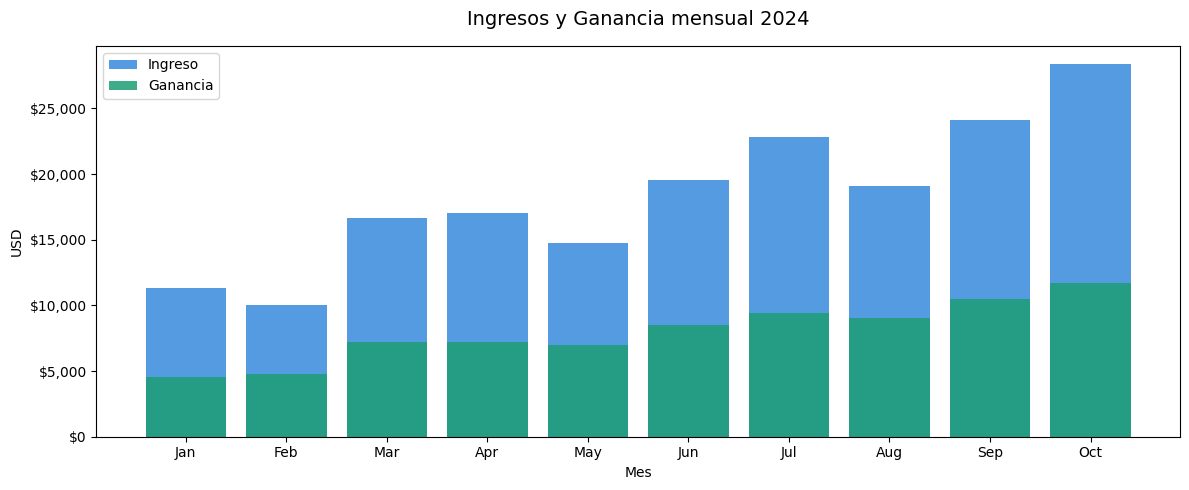

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(resumen_mes['mes'], resumen_mes['ingreso'], label='Ingreso', color='#378ADD', alpha=0.85)
ax.bar(resumen_mes['mes'], resumen_mes['ganancia'], label='Ganancia', color='#1D9E75', alpha=0.85)

ax.set_title('Ingresos y Ganancia mensual 2024', fontsize=14, pad=15)
ax.set_xlabel('Mes')
ax.set_ylabel('USD')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('ingresos_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()

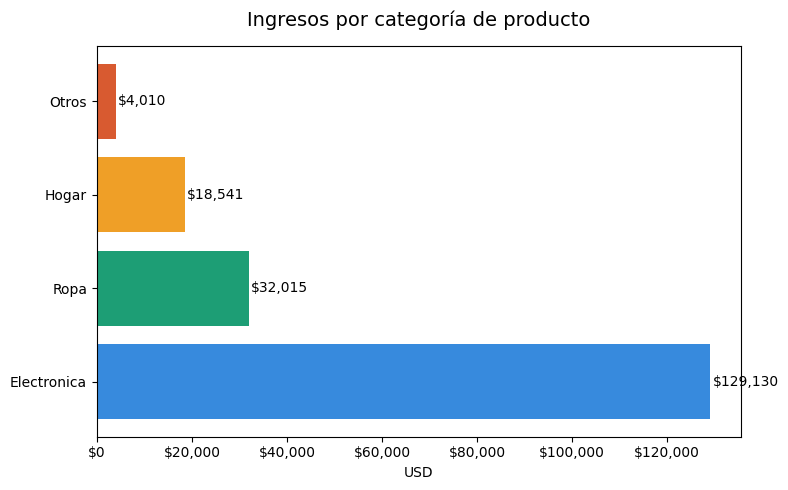

In [5]:
resumen_categoria = df.groupby('categoria')[['ingreso', 'ganancia']].sum().reset_index()
resumen_categoria = resumen_categoria.sort_values('ingreso', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

colores = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']
bars = ax.barh(resumen_categoria['categoria'], resumen_categoria['ingreso'], color=colores)

ax.set_title('Ingresos por categoría de producto', fontsize=14, pad=15)
ax.set_xlabel('USD')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, valor in zip(bars, resumen_categoria['ingreso']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${valor:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('ventas_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

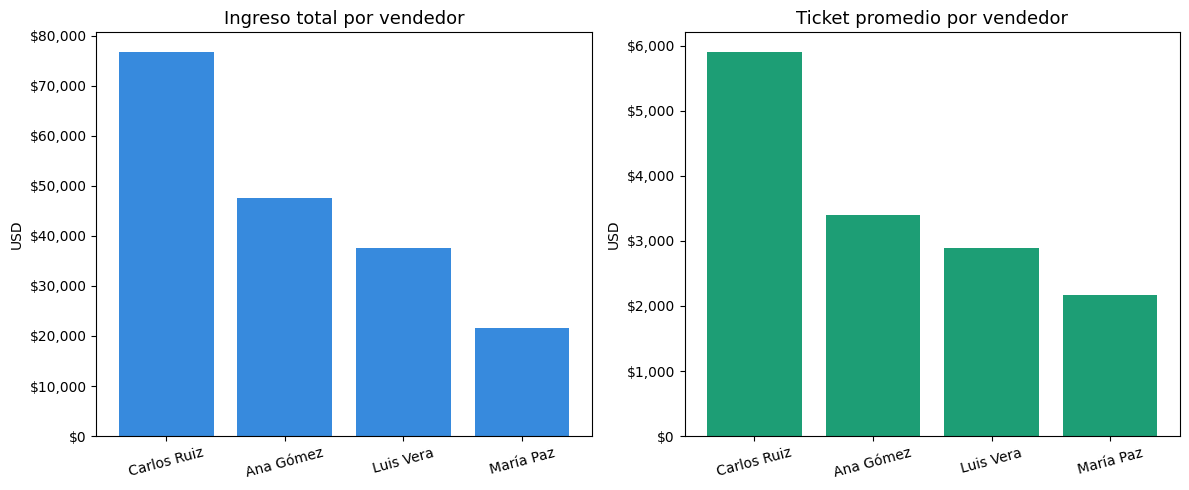

   vendedor  ingreso_total  ganancia_total  num_ventas  ticket_promedio
Carlos Ruiz          76825           28800          13      5909.615385
  Ana Gómez          47658           20568          14      3404.142857
  Luis Vera          37537           19197          13      2887.461538
  María Paz          21676           11357          10      2167.600000


In [6]:
resumen_vendedor = df.groupby('vendedor').agg(
    ingreso_total=('ingreso', 'sum'),
    ganancia_total=('ganancia', 'sum'),
    num_ventas=('ingreso', 'count'),
    ticket_promedio=('ingreso', 'mean')
).reset_index()

resumen_vendedor = resumen_vendedor.sort_values('ingreso_total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1 — Ingreso total por vendedor
axes[0].bar(resumen_vendedor['vendedor'], resumen_vendedor['ingreso_total'], color='#378ADD')
axes[0].set_title('Ingreso total por vendedor', fontsize=13)
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

# Gráfica 2 — Ticket promedio por vendedor
axes[1].bar(resumen_vendedor['vendedor'], resumen_vendedor['ticket_promedio'], color='#1D9E75')
axes[1].set_title('Ticket promedio por vendedor', fontsize=13)
axes[1].set_ylabel('USD')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('rendimiento_vendedores.png', dpi=150, bbox_inches='tight')
plt.show()

print(resumen_vendedor.to_string(index=False))

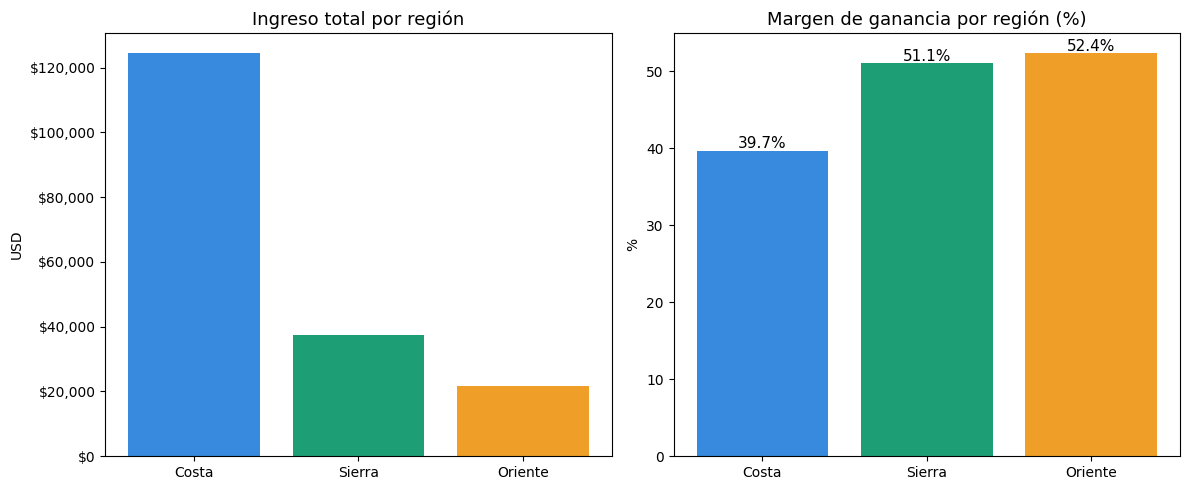

 region  ingreso_total  ganancia_total  num_ventas  margen_%
  Costa         124483           49368          27      39.7
 Sierra          37537           19197          13      51.1
Oriente          21676           11357          10      52.4


In [7]:
resumen_region = df.groupby('region').agg(
    ingreso_total=('ingreso', 'sum'),
    ganancia_total=('ganancia', 'sum'),
    num_ventas=('ingreso', 'count')
).reset_index()

resumen_region['margen_%'] = (resumen_region['ganancia_total'] / resumen_region['ingreso_total'] * 100).round(1)
resumen_region = resumen_region.sort_values('ingreso_total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1 — Ingreso por región
colores = ['#378ADD', '#1D9E75', '#EF9F27']
axes[0].bar(resumen_region['region'], resumen_region['ingreso_total'], color=colores)
axes[0].set_title('Ingreso total por región', fontsize=13)
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Gráfica 2 — Margen por región
axes[1].bar(resumen_region['region'], resumen_region['margen_%'], color=colores)
axes[1].set_title('Margen de ganancia por región (%)', fontsize=13)
axes[1].set_ylabel('%')
for bar, val in zip(axes[1].patches, resumen_region['margen_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('ventas_region.png', dpi=150, bbox_inches='tight')
plt.show()

print(resumen_region.to_string(index=False))